In [12]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import sys
import os
import matplotlib.pyplot as plt

# Subimos un nivel en el árbol de directorios ("..") y lo añadimos al path
path_raiz = os.path.abspath("..")
if path_raiz not in sys.path:
    sys.path.append(path_raiz)

from utils.plots import plot_decision_regions
from models.LinearNeuron import LogisticRegressionGD

X, y = load_iris(return_X_y=True, as_frame=True)
X = X.iloc[:,[2,3]]
X = X.values
X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=1, shuffle=True, stratify=y
    )
ss = StandardScaler()
ss.fit(X_train)
X_train_std = ss.transform(X_train)
X_test_std = ss.transform(X_test)

# Logistic Regression

1. **Probabilistic Foundation**: It is a probabilistic model that calculates the conditional probability of the positive event occurring, given the features of a specific instance: 
   $p := p(y=1|\mathbf{x})$

2. **The Odds**: The mathematical formulation begins with the **odds**, representing the ratio of the probability of the positive event to the probability of the negative event: 
   $$\text{Odds} = \frac{p}{(1-p)}$$

3. **The Logit Function**: By taking the natural logarithm of the odds, we obtain the **logit** (log-odds) function: 
   $$\text{logit}(p) = \log\left(\frac{p}{1 - p}\right)$$

4. **Linear Assumption**: Because the logit function maps probabilities to the entire real-number range $[-\infty, \infty]$, we can model it as a linear combination of the input features and weights (net input $z$): 
   $$\text{logit}(p) = \mathbf{w}^T \mathbf{x} + b = z$$

5. **The Sigmoid Activation**: Solving the previous equation for the probability $p$ yields the inverse logit, known as the **logistic sigmoid function**. This function maps the linear output back to a $[0, 1]$ range, serving as the activation function: 
   $$\sigma(z) = \frac{1}{1 + e^{-z}}$$

6. **Likelihood Function**: Assuming all training instances are independent, we can define a **likelihood function** ($\mathcal{L}$) based on a Bernoulli distribution to measure how well the model explains the observed data: 
   $$\mathcal{L}(\mathbf{w}, b|\mathbf{x}) = \prod_{i=1}^{n} \left(\sigma(z^{(i)})\right)^{y^{(i)}} \left(1 - \sigma(z^{(i)})\right)^{1-y^{(i)}}$$

7. **Log-Likelihood**: To avoid numerical underflow from multiplying many small probabilities, we apply the natural logarithm. This transforms the product into a mathematically convenient summation: 
   $$l(\mathbf{w}, b|\mathbf{x}) = \sum_{i=1}^{n} \left[ y^{(i)} \log(\sigma(z^{(i)})) + (1 - y^{(i)}) \log(1 - \sigma(z^{(i)})) \right]$$

8. **Logistic Loss Function**: The goal is to maximize the log-likelihood. However, in optimization, we typically minimize a cost. Maximizing the log-likelihood is identical to minimizing the **negative log-likelihood**, which gives us our loss function ($L$) to use with Gradient Descent: 
   $$L(\mathbf{w}, b) = \sum_{i=1}^{n} \left[ -y^{(i)} \log(\sigma(z^{(i)})) - (1 - y^{(i)}) \log(1 - \sigma(z^{(i)})) \right]$$

9. **Gradient Descent Update**: After applying the chain rule, the partial derivatives of the logistic loss function simplify perfectly. The resulting weight update rule is mathematically identical to the one used in **ADALINE**: 
   $$w_j := w_j + \eta \sum_{i=1}^{n} \left(y^{(i)} - \sigma(z^{(i)})\right)x_j^{(i)}$$
```

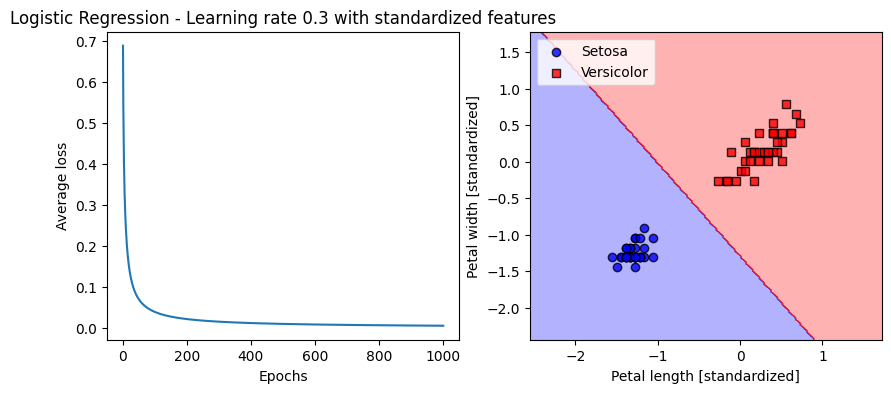

In [13]:
X_train_std_01_subset = X_train_std[(y_train == 0) | (y_train == 1)]

y_train_01_subset = y_train[(y_train == 0) | (y_train == 1)]
my_LR = LogisticRegressionGD(
    eta=0.3, epochs=1000, random_seed=1
)
my_LR.fit(X_train_std_01_subset, y_train_01_subset)

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10,4))
ax[0].plot(range(1,len(my_LR.losses_)+1), my_LR.losses_)
ax[0].set_xlabel("Epochs")
ax[0].set_ylabel("Average loss")
ax[0].set_title("Logistic Regression - Learning rate 0.3 with standardized features")
plot_decision_regions(X_train_std_01_subset, y_train_01_subset, algorithm=my_LR)
ax[1].set_xlabel("Petal length [standardized]")
ax[1].set_ylabel("Petal width [standardized]")
ax[1].legend(loc="upper left")
# ax[1].tight_layout()
plt.show()

## SKLearn

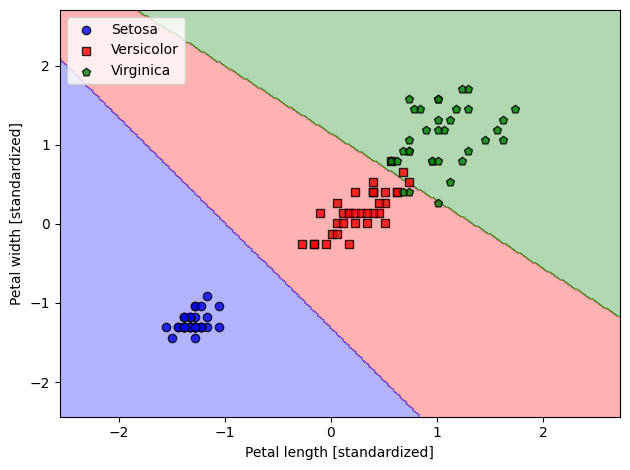

In [14]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(solver='lbfgs')
lr.fit(X_train_std, y_train)
plot_decision_regions(X_train_std,y_train,algorithm=lr)
plt.xlabel('Petal length [standardized]')
plt.ylabel('Petal width [standardized]')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

## Regularization to tackl overfitting

1. **The Penalized Cost Function**: L2 regularization prevents overfitting by adding a penalty term (the sum of the squared weights) to the original loss function. The model is now forced to minimize the prediction error while keeping the weights as small as possible:
   $$Loss_{total} = Loss_{original} + \frac{\lambda}{2n} \sum_{j=1}^{m} w_j^2$$
   Consequently, the partial derivative with respect to each weight ($w_j$) used for the gradient descent update includes an additional term that shrinks the weight:
   $$\frac{\partial Loss_{total}}{\partial w_j} = \frac{\partial Loss_{original}}{\partial w_j} + \frac{\lambda}{n} w_j$$

2. **The $\lambda$ Parameter (Regularization Strength)**: This hyperparameter controls the bias-variance tradeoff:
   * **$\lambda = 0$**: No penalty is applied (High risk of overfitting / High variance).
   * **Large $\lambda$**: Heavily penalizes large weights, pushing them toward zero (Reduces variance, but making it too large risks underfitting / High bias).

3. **Implementation Golden Rules**:
   * **Feature Standardization is Mandatory**: Because the penalty targets the mathematical magnitude of the weights, all features must be on the exact same scale so they are penalized fairly.
   * **The Bias Term ($b$) is Excluded**: The bias (or intercept) only shifts the decision boundary in space; it does not increase its geometrical complexity or cause overfitting, so it is never regularized.

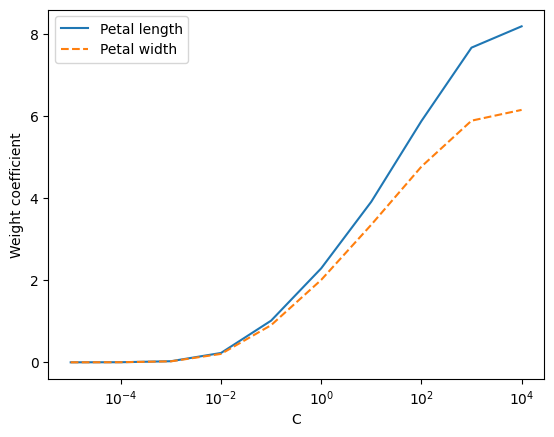

In [13]:
weights, params = [], []
for c in np.arange(-5, 5):
    lr = LogisticRegression(C=10.**c)
    lr.fit(X_train_std_01_subset, y_train_01_subset)
    weights.append(lr.coef_[0])
    params.append(10.**c)
weights = np.array(weights)
plt.plot(params, weights[:, 0],
label='Petal length')
plt.plot(params, weights[:, 1], linestyle='--',
label='Petal width')
plt.ylabel('Weight coefficient')
plt.xlabel('C')
plt.legend(loc='upper left')
plt.xscale('log')
plt.show()

# Support Vector Machine

# Decision tree

**1. Maximizing Information Gain (IG)**
The primary objective function when learning a decision tree is to maximize the **Information Gain (IG)** at each split. IG calculates the difference between the impurity of the parent node and the weighted sum of the child nodes' impurities. By maximizing IG, the algorithm ensures that each split results in the most informative child nodes. For binary splits, it is defined as:
$$IG(D_p, f) = I(D_p) - \frac{N_{left}}{N_p} I(D_{left}) - \frac{N_{right}}{N_p} I(D_{right})$$

**2. Measures of Impurity**
To calculate the Information Gain, the algorithm relies on an impurity metric ($I$). The three most common criteria are:
*   **Entropy ($I_H$)**: Measures the uncertainty in a node. It attempts to maximize the mutual information in the tree. 
    $$I_H(t) = - \sum_{i=1}^{c} p(i|t) \log_2 p(i|t)$$
*   **Gini Impurity ($I_G$)**: A criterion that minimizes the probability of misclassification. In practice, it yields very similar results to Entropy.
    $$I_G(t) = 1 - \sum_{i=1}^{c} p(i|t)^2$$
*   **Classification Error ($I_E$)**: A simpler metric based purely on the majority class of the node.
    $$I_E(t) = 1 - \max\{p(i|t)\}$$

**3. The Insensitivity of Classification Error and Pruning**
The **Classification Error** is useful for evaluating a tree but *not* recommended for growing it. Because it is a linear function, it is **less sensitive** to changes in class probabilities and fails to reward splits that create purely homogeneous nodes. 

Furthermore, because Gini and Entropy perform almost identically, it is far more important to focus on optimizing **pruning cut-offs** (like setting a maximum depth). Without pruning, a decision tree will expand limitlessly until every node is pure, leading to severe **overfitting**.

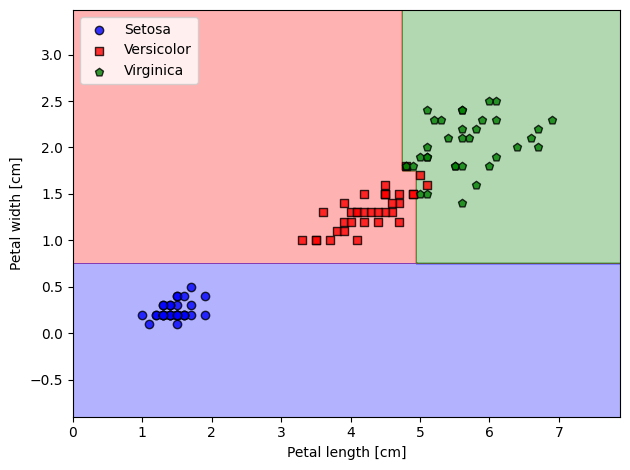

In [15]:
from sklearn.tree import DecisionTreeClassifier
tree_model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=4,
    random_state=1
)
tree_model.fit(X=X_train, y=y_train)
plot_decision_regions(X_train, y_train, algorithm=tree_model)
plt.xlabel('Petal length [cm]')
plt.ylabel('Petal width [cm]')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

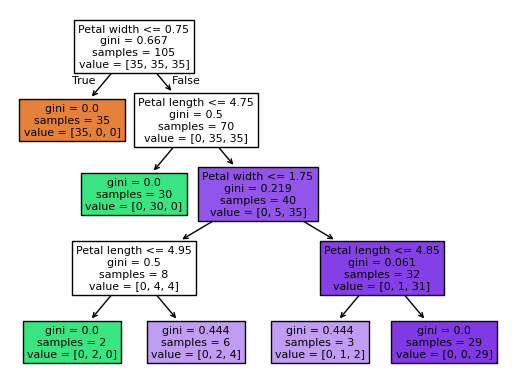

In [17]:
from sklearn import tree
feature_names = ['Petal length', 'Petal width']
tree.plot_tree(tree_model,
 feature_names=feature_names,
 filled=True)
plt.show()

## Random Forest

**The Ensemble Concept**
An ensemble is a machine learning technique that combines multiple individual models to build a single, more robust model. Specifically, a Random Forest is an ensemble of decision trees. By averaging the results of multiple deep trees—which individually suffer from high variance—the ensemble achieves better generalization and significantly reduces the risk of overfitting.

**The 4-Step Algorithm**
1. **Bootstrap Sampling**: Draw a random bootstrap sample of size $n$ by selecting $n$ examples from your training dataset *with replacement*.
2. **Grow the Tree**: Train a decision tree using this bootstrap sample. To ensure diversity, apply a special rule at each node:
   * Randomly select a subset of $d$ features *without replacement*.
   * Split the node using only the feature from this subset that provides the best split (e.g., maximizing Information Gain).
3. **Repeat**: Repeat steps 1 and 2 exactly $k$ times to generate a "forest" of $k$ distinct decision trees.
4. **Aggregate**: Collect the predictions from all $k$ trees and assign the final class label based on a **majority vote**.

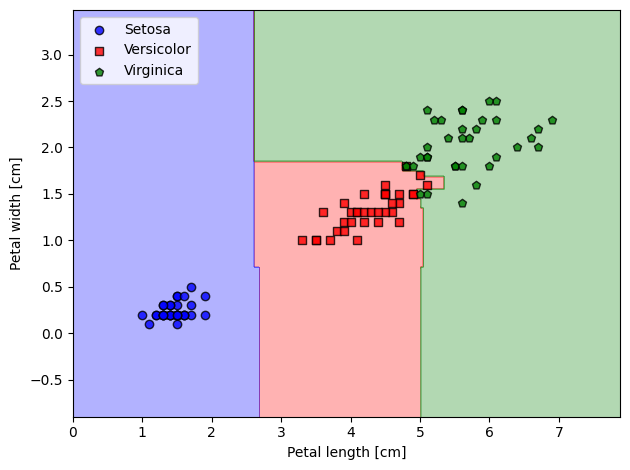

In [18]:
from sklearn.ensemble import RandomForestClassifier
forest = RandomForestClassifier(
    n_estimators=25,
    random_state=1,
    n_jobs=4
)
forest.fit(X_train, y_train)
plot_decision_regions(X_train, y_train, algorithm=forest)
plt.xlabel('Petal length [cm]')
plt.ylabel('Petal width [cm]')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

# $k$-Nearest Neighbors

A Non-Parametric, "Lazy" Learner**
* **Non-parametric:** Unlike models with fixed equations (like logistic regression), KNN does not have a fixed set of parameters. Instead, the number of parameters grows as the amount of training data increases.
* **Lazy Learning (Instance-based):** KNN doesn't actually "train" or build a model in advance. It simply memorizes the entire training dataset. Because of this, the initial training phase has essentially zero computation cost.

**The 3-Step Algorithm**

When a new, unseen data point needs to be classified, the algorithm executes the following straightforward steps:
1. **Choose Parameters:** Select the number of neighbors ($k$) and a mathematical distance metric to measure closeness.
2. **Find Neighbors:** Calculate the distance between the new data record and all memorized training records to identify the $k$-nearest neighbors.
3. **Majority Vote:** Assign the final class label to the new point based on the most frequent class among those $k$ neighbors.

**Key Considerations for KNN**

*   **Choosing $k$:** Selecting the *right* value for $k$ is crucial to find a good balance between overfitting and underfitting the model.
*   **Distance Metrics & Standardization:** It is important to choose an appropriate distance metric and to strictly standardize the data so all features contribute equally to the distance calculation. A common generalized metric is the **Minkowski distance**:
    $$d(\mathbf{x}^{(i)}, \mathbf{x}^{(j)}) = \sqrt[p]{\sum_k |x_k^{(i)} - x_k^{(j)}|^p}$$
    This formula becomes the Manhattan distance when $p=1$, and the Euclidean distance when $p=2$.
*   **The Curse of Dimensionality:** KNN is highly susceptible to overfitting in datasets with many features. As dimensions increase, the feature space becomes increasingly sparse; this means that even the "closest" neighbors are actually too far away to provide a good or reliable estimate.

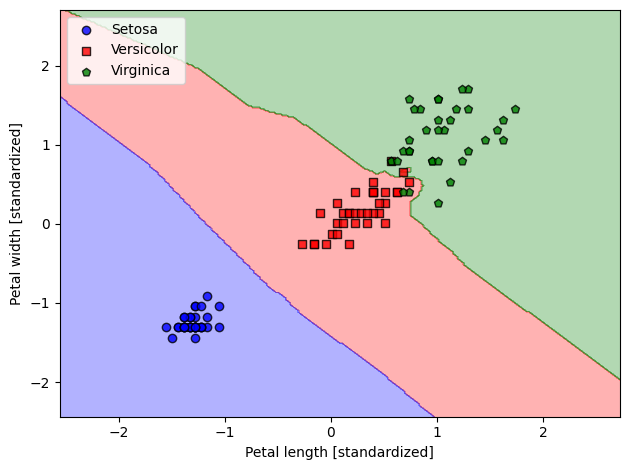

In [19]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=5, p=2, metric='minkowski')
knn.fit(X_train_std, y_train)
plot_decision_regions(X_train_std, y_train, algorithm=knn)
plt.xlabel('Petal length [standardized]')
plt.ylabel('Petal width [standardized]')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()